In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

In [2]:
df = pd.read_csv('..\\data\\mega_FA_bathy.csv')
df.head()

,lat,long,age,q_ihfc,q_ps,q_stein,FA,ps_z,stein_z,bathy
0,49.62,-129.98,0.816961,366.0,523.431597,564.247252,2.029732,2816.350677,2929.908563,-2408
1,44.68,-125.29,9.119624,79.0,156.665075,168.881356,-66.546684,3556.955038,3702.253111,-2114
2,44.66,-125.27,9.119624,81.0,156.665075,168.881356,-66.546684,3556.955038,3702.253111,-2269
3,44.66,-125.27,9.119624,93.0,156.665075,168.881356,-66.546684,3556.955038,3702.253111,-2269
4,44.66,-125.26,9.119624,77.0,156.665075,168.881356,-66.546684,3556.955038,3702.253111,-2280


note that y = df[['ps_q']] will make the shape (#,#) but y = df['ps_q'] will make the shape (#,)

In [3]:
x = df.drop(columns=['q_ps', 'q_stein', 'ps_z', 'stein_z', 'FA'])
y = df['FA']

In [4]:
x.head()

,lat,long,age,q_ihfc,bathy
0,49.62,-129.98,0.816961,366.0,-2408
1,44.68,-125.29,9.119624,79.0,-2114
2,44.66,-125.27,9.119624,81.0,-2269
3,44.66,-125.27,9.119624,93.0,-2269
4,44.66,-125.26,9.119624,77.0,-2280


In [5]:
x.shape

(7445, 5)

In [6]:
y.head()

0     2.029732
1   -66.546684
2   -66.546684
3   -66.546684
4   -66.546684
Name: FA, dtype: float64

In [7]:
ts = 0.2

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=ts)

In [8]:
x_train.shape

(5956, 5)

this is the raw validation data

In [9]:
x_test.shape

(1489, 5)

In [10]:
x_train.describe().round(3)

,lat,long,age,q_ihfc,bathy
count,5956.000,5956.000,5956.000,5956.000,5956.000
mean,46.184,-125.748,6.227,618.193,-1249.657
std,3.534,3.553,5.992,1722.805,1685.107
min,37.030,-132.420,0.010,-182.200,-4764.000
25%,44.590,-128.680,0.817,86.600,-2585.000
50%,47.850,-127.660,3.578,187.000,-2418.000
75%,48.450,-122.530,9.544,410.000,581.000
max,54.940,-119.000,35.200,26000.000,2860.000


In [11]:
x_test.describe().round(3)

,lat,long,age,q_ihfc,bathy
count,1489.000,1489.000,1489.000,1489.000,1489.000
mean,46.147,-125.685,6.291,571.518,-1203.880
std,3.610,3.583,6.008,1389.841,1681.295
min,37.030,-132.220,0.021,4.000,-4506.000
25%,44.240,-128.680,0.806,87.000,-2584.000
50%,47.860,-127.680,3.453,198.000,-2410.000
75%,48.450,-122.400,9.545,420.000,549.000
max,54.910,-119.000,33.939,18700.000,2002.000


In [12]:
train_data = lgb.Dataset(x_train, label = y_train)
test_data = lgb.Dataset(x_test, label = y_test)

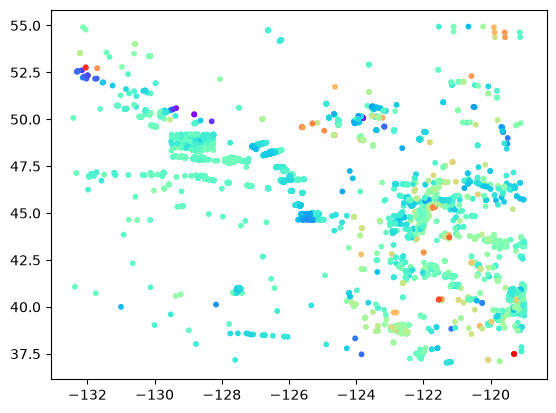

In [13]:
plt.scatter(x_train['long'], x_train['lat'], 
            c=y_train, cmap='rainbow', marker='o', s=10)

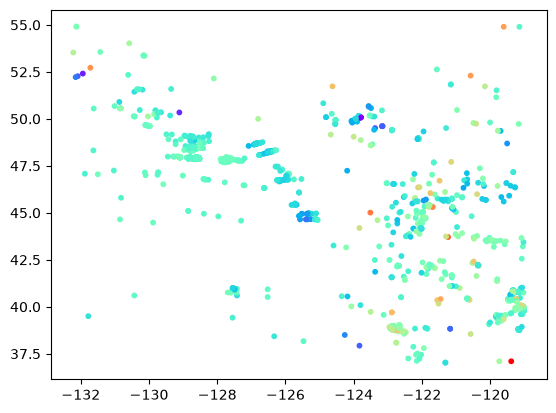

In [14]:
plt.scatter(x_test['long'], x_test['lat'], 
            c=y_test, cmap='rainbow', marker='o', s=10)

In [15]:
lr = 0.1

params = {
    'objective':'regression',
    'metric':'rmse',
    'boosting_type':'gbdt',
    'learning_rate':lr,
    'verbose':1
}

In [16]:
nbr = 100
model = lgb.train(params, train_data, valid_sets = [test_data], num_boost_round=nbr)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000426 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1241
[LightGBM] [Info] Number of data points in the train set: 5956, number of used features: 5
[LightGBM] [Info] Start training from score -6.951777


In [17]:
y_pred = model.predict(x_test)

In [18]:
y_pred.shape

(1489,)

In [19]:
y_pred, y_pred.shape

(array([-23.83941633,  57.28461426,  17.77068748, ...,  18.21434516,
        -10.68457697, -10.68457697], shape=(1489,)),
 (1489,))

In [20]:
residuals = y_test - y_pred

negative mean: overpredicting

In [21]:
residuals.head(), residuals.describe()

(3704     1.858175
 1059    11.918259
 5544     6.671636
 1844    -9.734834
 4357    -0.064665
 Name: FA, dtype: float64,
 count    1489.000000
 mean        0.026289
 std        11.389120
 min       -64.127632
 25%        -2.223838
 50%        -0.282600
 75%         2.356523
 max        86.701115
 Name: FA, dtype: float64)

In [22]:
dfr = pd.DataFrame({
    'long': x_test['long'].values,
    'lat': x_test['lat'].values,
    'ps_q_test_data': y_test,
    'ps_q_predicted': y_pred,
    'residual': residuals
})

saving both the csv file and a text file of specified parameters

In [23]:
pd.DataFrame(dfr).to_csv('..\\created_data\\Cbth_grav_residuals.csv', index=False)

with open('..\\created_data\\Cbth_grav_params.txt', 'w') as f:
    f.write('saving parameters for this dataset...\n')
    f.write(f'learning rate: {lr}\nnum_boost_rate: {nbr}\ntest size: {ts}\n')
    f.write(f'gives mean of: {residuals.mean()}')
    f.write(f'and this was for lat, long, age, ihfc, and bathy')

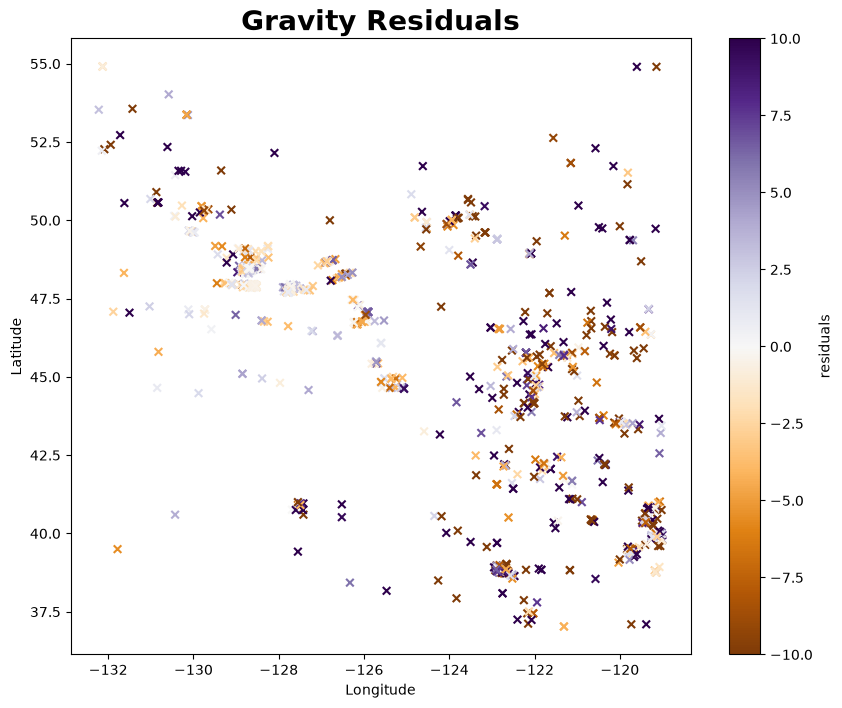

In [24]:
plt.figure(figsize=(10, 8))
plt.scatter(x_test['long'], x_test['lat'], c=residuals, cmap='PuOr',
            marker='x', s=30, vmin=-10, vmax=10)
plt.colorbar(label='residuals')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Gravity Residuals', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})

plt.savefig('..\\figs\\grav\\Cbth_res_grav.png', dpi=400)
plt.show()

## now we ... predict!

we start with just predicting the same area on an empty grid

In [25]:
sp = 250
grid_long = np.linspace(x_test['long'].min(), x_test['long'].max(), sp)
grid_lat = np.linspace(x_test['lat'].min(), x_test['lat'].max(), sp)

In [26]:
long, lat = np.meshgrid(grid_long, grid_lat)

In [27]:
long.shape, lat.shape

((250, 250), (250, 250))

Nearest copies the value of the closest data point, keeping original values sharp but blocky. Linear blends adjacent points using a straight line or weighted average.

In [28]:
age_interp = griddata((df['long'], df['lat']), df['age'], (long, lat), method='linear')
hf_interp  = griddata((df['long'], df['lat']), df['q_ihfc'], (long, lat), method='linear')
bathy_interp = griddata((df['long'], df['lat']), df['bathy'], (long, lat), method='linear')

In [29]:
np.where(~np.isnan(age_interp))

(array([  1,   1,   1, ..., 249, 249, 249], shape=(60051,)),
 array([145, 146, 147, ..., 239, 240, 241], shape=(60051,)))

In [30]:
hf_interp[130:135, 130:135], age_interp[130:135, 130:135], bathy_interp[130:135, 130:135]

(array([[73.57976406, 71.70012342, 69.82048278, 67.94084213, 66.06120149],
        [74.22585211, 72.34621147, 70.46657083, 68.58693018, 66.70728954],
        [74.87194016, 72.99229952, 71.11265888, 69.23301823, 67.35337759],
        [75.51802821, 73.63838757, 71.75874693, 69.87910628, 68.09568665],
        [76.16411626, 74.30621522, 72.53781641, 70.7694176 , 69.00101879]]),
 array([[8.57933883, 8.63912725, 8.69891567, 8.7587041 , 8.81849252],
        [8.60002033, 8.65980875, 8.71959718, 8.7793856 , 8.83917403],
        [8.62070183, 8.68049026, 8.74027868, 8.8000671 , 8.85985553],
        [8.64138334, 8.70117176, 8.76096018, 8.82074861, 8.87104763],
        [8.66206484, 8.71970929, 8.76852694, 8.8173446 , 8.86616226]]),
 array([[-1689.50710366, -1593.39614167, -1497.28517969, -1401.17421771,
         -1305.06325572],
        [-1663.04994553, -1566.93898354, -1470.82802156, -1374.71705958,
         -1278.60609759],
        [-1636.5927874 , -1540.48182541, -1444.37086343, -1348.25990144,


In [31]:
age_interp.shape, hf_interp.shape, bathy_interp.shape

((250, 250), (250, 250), (250, 250))

np.vstack stacks arrays as new rows

In [32]:
lola = np.vstack([long.ravel(), lat.ravel(), age_interp.ravel(), hf_interp.ravel(), bathy_interp.ravel()]).T

In [33]:
lola.shape

(62500, 5)

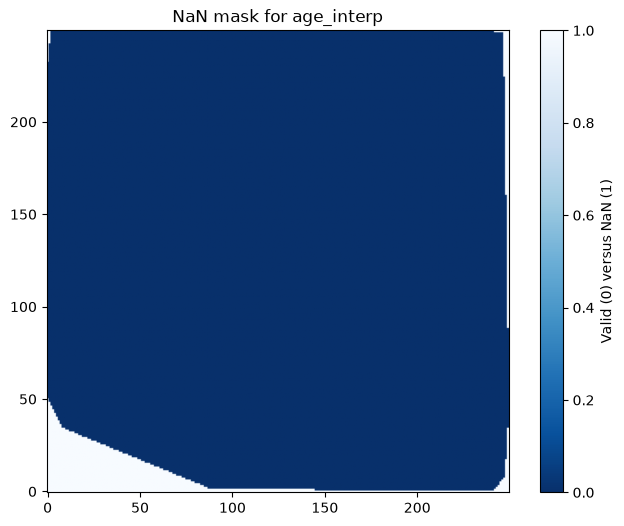

In [34]:
np.where(np.isnan(lola))

plt.figure(figsize=(8,6))
plt.imshow(np.isnan(age_interp), origin='lower', cmap='Blues_r', vmin=0, vmax=1)
plt.title('NaN mask for age_interp')
plt.colorbar(label='Valid (0) versus NaN (1)')
plt.show()

In [35]:
lola_pred = model.predict(lola)

In [36]:
lola_pred[180:184]

array([-0.18405831, -0.18405831, -0.18405831, -0.18405831])

In [37]:
lola_pred = lola_pred.reshape(long.shape)

In [38]:
lola_pred.shape

(250, 250)

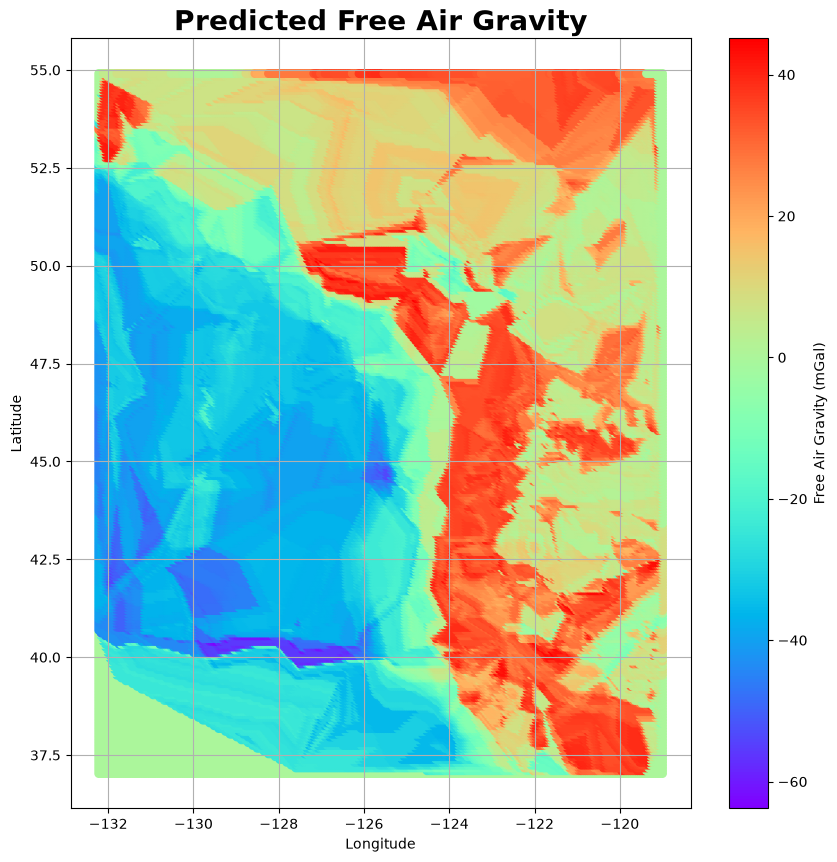

In [39]:
plt.figure(figsize=(10, 10))
plt.scatter(long, lat, c=lola_pred, cmap='rainbow', marker='o', s=30)
plt.colorbar(label='Free Air Gravity (mGal)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Predicted Free Air Gravity', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})
plt.grid()

plt.savefig(f'..\\figs\\grav\\Cbth_grav_pred_{sp}.png', dpi=400)
plt.show()

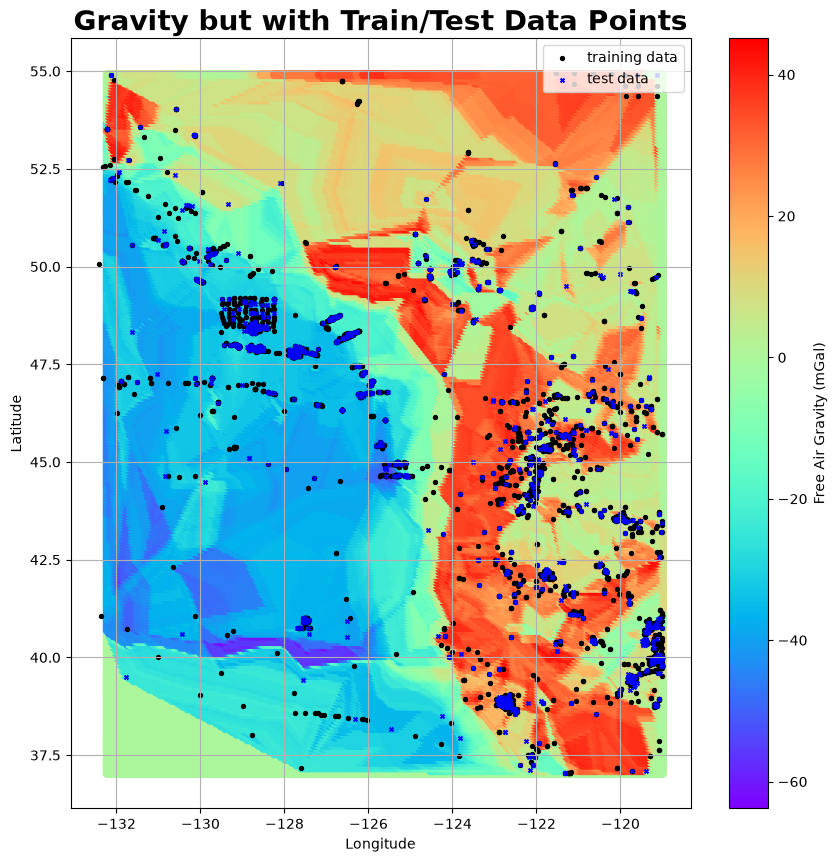

In [40]:
plt.figure(figsize=(10, 10))
plt.scatter(long, lat, c=lola_pred, cmap='rainbow', marker='o', s=30)
plt.colorbar(label='Free Air Gravity (mGal)')
plt.scatter(x_train['long'], x_train['lat'], marker='o', color='black', s=8, label='training data')
plt.scatter(x_test['long'], x_test['lat'], marker='x', color='blue', s=8, label='test data')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Gravity but with Train/Test Data Points', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})
plt.legend(loc='upper right')
plt.grid()

plt.savefig(f'..\\figs\\grav\\Cbth_grav_pnts_pred_{sp}.png', dpi=400)
plt.show()

## now the predicton will be from a specified area...

In [41]:
sp = 250
grid_long = np.linspace(-130, -128, sp)
grid_lat = np.linspace(47.5, 50, sp)

In [42]:
long, lat = np.meshgrid(grid_long, grid_lat)

In [43]:
long.shape, lat.shape

((250, 250), (250, 250))

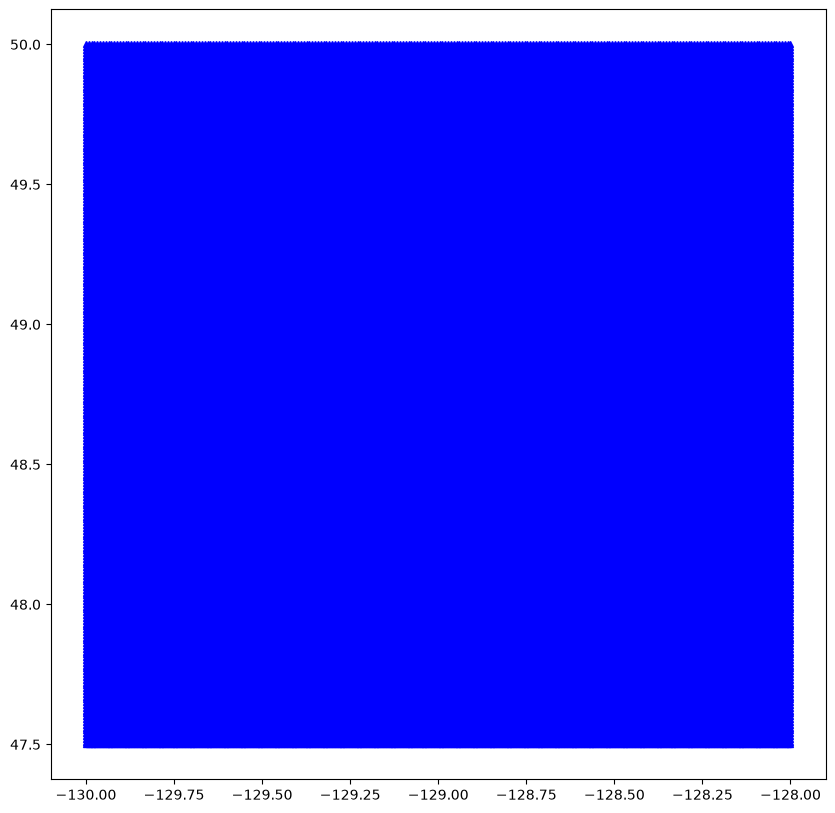

In [44]:
plt.figure(figsize=(10, 10))
plt.plot(long, lat, marker='^', markersize=5, color='blue', linestyle='none')
plt.show()

In [45]:
age_interp = griddata((df['long'], df['lat']), df['age'], (long, lat), method='linear')
hf_interp  = griddata((df['long'], df['lat']), df['q_ihfc'], (long, lat), method='linear')
bathy_interp = griddata((df['long'], df['lat']), df['bathy'], (long, lat), method='linear')

In [46]:
np.where(~np.isnan(age_interp))

(array([  0,   0,   0, ..., 249, 249, 249], shape=(62500,)),
 array([  0,   1,   2, ..., 247, 248, 249], shape=(62500,)))

In [47]:
hf_interp[130:135, 130:135], age_interp[130:135, 130:135], bathy_interp[130:135, 130:135]

(array([[133.43122203, 145.03076305, 156.63030407, 165.20736369,
         165.12581717],
        [127.96087698, 137.05170396, 148.65124498, 153.57796474,
         153.49641822],
        [143.21065159, 136.22712565, 140.67218589, 141.94856579,
         141.86701926],
        [145.52449868, 142.71693698, 154.69168579, 145.1001769 ,
         140.46510928],
        [164.64179024, 177.28353671, 189.25828552, 179.66677663,
         170.07526774]]),
 array([[0.34024645, 0.32670458, 0.31316272, 0.30837553, 0.32866819],
        [0.33908669, 0.32905298, 0.31551111, 0.32129722, 0.34158988],
        [0.30895213, 0.32139663, 0.31785951, 0.33421891, 0.35451157],
        [0.3380433 , 0.34622147, 0.40191033, 0.41987498, 0.44192113],
        [0.44351357, 0.50036916, 0.55605802, 0.57402267, 0.59198732]]),
 array([[-2471.30263913, -2476.35140562, -2481.40017212, -2487.1645225 ,
         -2494.97883058],
        [-2446.78081715, -2450.31870338, -2455.36746988, -2461.996052  ,
         -2469.81036008],
   

In [48]:
age_interp.shape, hf_interp.shape, bathy_interp.shape

((250, 250), (250, 250), (250, 250))

In [49]:
lola = np.vstack([long.ravel(), lat.ravel(), age_interp.ravel(), hf_interp.ravel(), bathy_interp.ravel()]).T

In [50]:
lola.shape

(62500, 5)

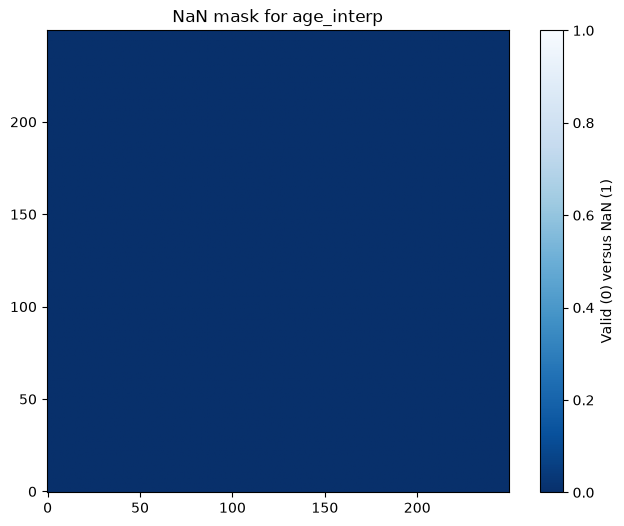

In [51]:
np.where(np.isnan(lola))

plt.figure(figsize=(8,6))
plt.imshow(np.isnan(age_interp), origin='lower', cmap='Blues_r', vmin=0, vmax=1)
plt.title('NaN mask for age_interp')
plt.colorbar(label='Valid (0) versus NaN (1)')
plt.show()

In [52]:
lola_pred = model.predict(lola)

In [53]:
lola_pred[180:184]

array([-31.7966277 , -31.7966277 , -31.7966277 , -32.12294336])

In [54]:
lola_pred = lola_pred.reshape(long.shape)

In [55]:
lola_pred.shape

(250, 250)

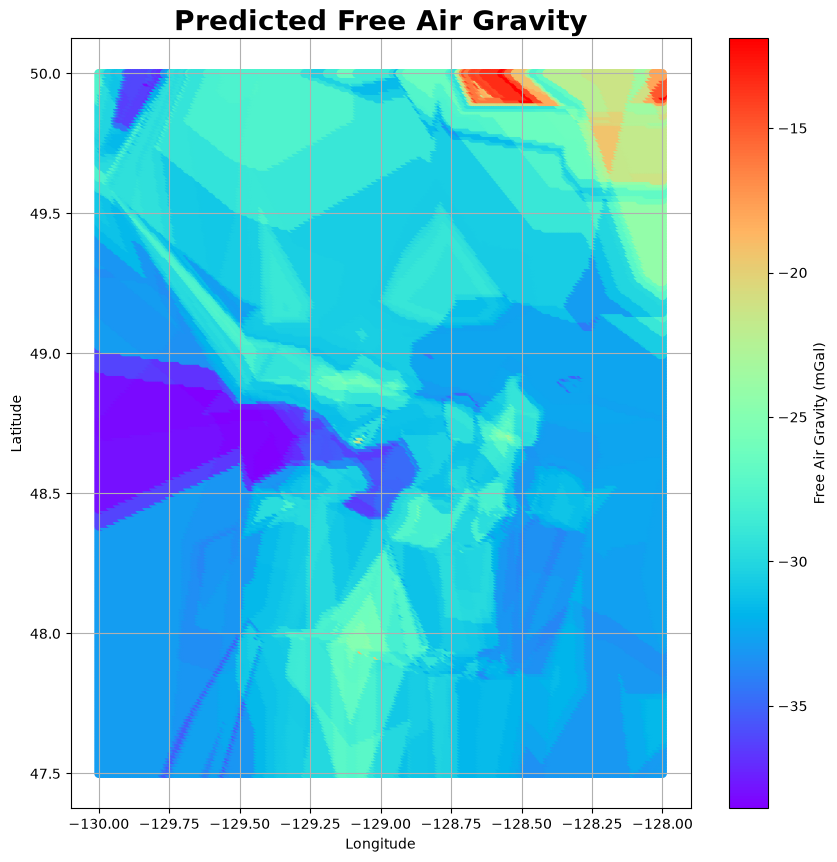

In [56]:
plt.figure(figsize=(10, 10))
plt.scatter(long, lat, c=lola_pred, cmap='rainbow', marker='o', s=30)
plt.colorbar(label='Free Air Gravity (mGal)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Predicted Free Air Gravity', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})
plt.grid()

plt.savefig(f'..\\figs\\grav\\Csmall_grav_pred_{sp}.png', dpi=400)
plt.show()

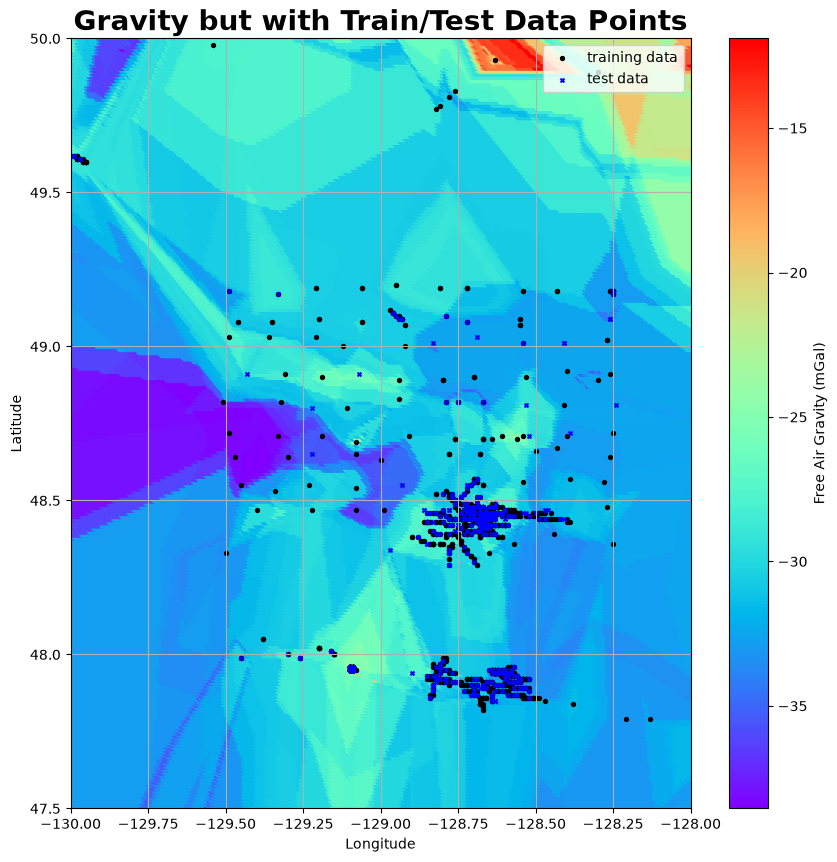

In [57]:
plt.figure(figsize=(10, 10))
plt.scatter(long, lat, c=lola_pred, cmap='rainbow', marker='o', s=30)
plt.colorbar(label='Free Air Gravity (mGal)')
plt.scatter(x_train['long'], x_train['lat'], marker='o', color='black', s=8, label='training data')
plt.scatter(x_test['long'], x_test['lat'], marker='x', color='blue', s=8, label='test data')
plt.xlim(-130, -128)
plt.ylim(47.5, 50)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Gravity but with Train/Test Data Points', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})
plt.legend(loc='upper right')
plt.grid()

plt.savefig(f'..\\figs\\grav\\Csmall_grav_pnts_pred_{sp}.png', dpi=400)
plt.show()